Develop:
beta dose heterogeneity. Fixed deviation for grains in a layer, new deviation for new grains. Base deviation on position in array, or are the positions mixed with transport?

In [150]:
include("Mixed-Signals_functions.jl")


## Define objects and parameters for soil and luminescence
bd = 1500               # Bulk density [kg m⁻³]
soildepth = 2           # Thickness of the entire soil profile [m]
nlayers = 100           # Number of soil layers
layer_thickness = 0.02  # Initial layer thickness [m]
bleaching_depth = 0.005 # Thickness of surface layer where bleaching occurs [m]
grains_per_layer = 200  # Initial number of layers per soil layer
beta_dose_variation = 0.3 # standard error of beta dose heterogeneity
dt = 1

# Define process-specific parameters 
BT_pot = 10             # Potential bioturbation rate [kg m⁻² a⁻¹]
dd = 1                  # Depth parameter [m⁻¹]
dd_exch = 10            # Depth parameter for subsurface mixing [m⁻¹]
ntime = 10000           # Number of simulation years


soil, ages = initialise_soil(soildepth, nlayers, layer_thickness, bleaching_depth, grains_per_layer)

([0.005 7.5 0.0025 0.005; 0.02 30.0 0.015 0.025; … ; 0.02 30.0 1.9550000000000014 1.9650000000000012; 0.0349999999999986 52.499999999997904 1.9825000000000008 1.9999999999999998], [[0.0 0.0 0.0 0.8137918162877116; 0.0 0.0 0.0 0.8342265475215488; … ; 0.0 0.0 0.0 0.512364201918095; 0.0 0.0 0.0 0.7133044268241238], [0.0 0.0 0.0 0.6811065232268436; 0.0 0.0 0.0 0.7435160770494209; … ; 0.0 0.0 0.0 1.078804358330266; 0.0 0.0 0.0 1.0061136472324514], [0.0 0.0 0.0 1.3054120212282645; 0.0 0.0 0.0 1.322921330516281; … ; 0.0 0.0 0.0 1.0134066411235725; 0.0 0.0 0.0 0.67606714339176], [0.0 0.0 0.0 1.3218475697140382; 0.0 0.0 0.0 0.7745000460152134; … ; 0.0 0.0 0.0 1.0779722391375457; 0.0 0.0 0.0 0.6407041967791203], [0.0 0.0 0.0 1.3741672279095711; 0.0 0.0 0.0 1.1604907609175548; … ; 0.0 0.0 0.0 0.7554616915181515; 0.0 0.0 0.0 1.5226282504036357], [0.0 0.0 0.0 1.1102581306002086; 0.0 0.0 0.0 1.2779984251976926; … ; 0.0 0.0 0.0 1.4292860376266494; 0.0 0.0 0.0 0.9316973500677349], [0.0 0.0 0.0 1.10744

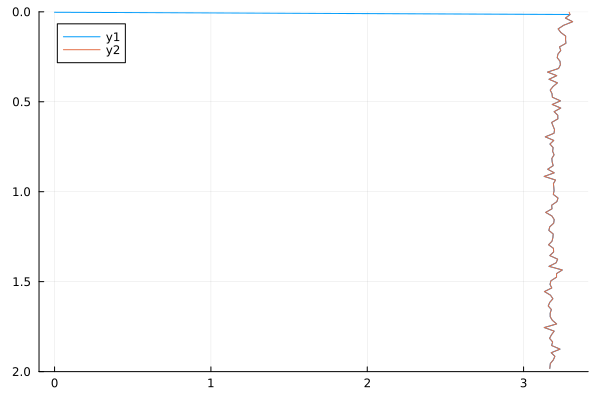

In [ ]:
dry_dose_rate = rand(Normal(3, 0.0)./1000, nlayers) # Gy a-1

soil, ages = soil, ages = initialise_soil(soildepth, nlayers, layer_thickness, bleaching_depth, grains_per_layer)
dt = 1
for t in 1:1000
    soil, ages = update_soil_and_luminescence(soil, ages)
end

plot([mean(sub[:,2]) for sub in ages], soil[:,3], ylim=(0,2)); yflip!(true)
plot!([mean(sub[:,3]) for sub in ages], soil[:,3])

#plot(plot([mean(sub[:,1]) for sub in ages], soil[:,3], ylim=(0,2))); yflip!(true)
# StatsPlots.density(ages[1][:,3])

In [151]:
# mounding

soil, ages = soil, ages = initialise_soil(soildepth, nlayers, layer_thickness, bleaching_depth, grains_per_layer)

for t in 1:1000
    soil, ages = BT_mounding(soil, ages, 1, "grd", 1)
    soil, ages = BT_mixing(soil, ages, 5, "grd", 1)
    soil, ages = update_soil_and_luminescence(soil, ages)
end

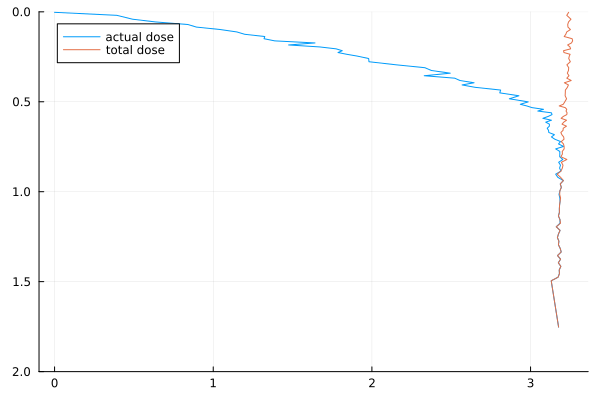

In [158]:
# soil[:,1]

plot([mean(sub[:,2]) for sub in ages], soil[:,3], ylim=(0,2), label = "actual dose"); yflip!(true)
plot!([mean(sub[:,3]) for sub in ages], soil[:,3], label = "total dose")


# l = 2
# scatter(ages[l][:,1], ages[l][:,2])

# plot(plot([mean(sub[:,1]) for sub in ages], soil[:,3], ylim=(0,2))); yflip!(true)
# plt = StatsPlots.density(ages[1][:,2])
# for l in 20:30
#     plt = (StatsPlots.density!(ages[l][:,2]))
# end

# plt


In [156]:
sum(soil[:,2])

2999.9999999999973